# 02 — Exploration des données formattées (Yahoo Finance)

Lecture du fichier `formatted/yahoofinance/wti.parquet` depuis S3 (LocalStack) pour vérifier le résultat du script `clean_yfinance.py`.

In [2]:
import io
import os
import boto3
import pandas as pd

# ── Connexion S3 LocalStack ──
os.environ["AWS_ACCESS_KEY_ID"] = "test"
os.environ["AWS_SECRET_ACCESS_KEY"] = "test"
os.environ["AWS_DEFAULT_REGION"] = "eu-west-1"

s3 = boto3.client("s3", endpoint_url="http://localhost:4566")

# ── Lecture du parquet formatté (dossier Spark) ──
# Spark écrit un dossier wti.parquet/ contenant _SUCCESS + part-*.parquet
prefix = "formatted/yahoofinance/wti.parquet/"
objs = s3.list_objects_v2(Bucket="datalake", Prefix=prefix)
parquet_key = [o["Key"] for o in objs.get("Contents", []) if o["Key"].endswith(".parquet")][0]

response = s3.get_object(Bucket="datalake", Key=parquet_key)
df = pd.read_parquet(io.BytesIO(response["Body"].read()), engine="pyarrow")

print(f"Shape : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nTypes :\n{df.dtypes}")
print(f"\nPlage : {df['Datetime'].min()} → {df['Datetime'].max()}")
df.head()

Shape : 620 lignes × 8 colonnes

Types :
Datetime            datetime64[ns]
Close                      float64
High                       float64
Low                        float64
Open                       float64
Volume                       int64
Volatility_Range           float64
Variation_Pct              float64
dtype: object

Plage : 2026-02-19 05:00:00 → 2026-02-27 21:45:00


,Datetime,Close,High,Low,Open,Volume,Volatility_Range,Variation_Pct
0,2026-02-19 05:00:00,65.290001,65.309998,65.220001,65.220001,251,0.09,NaN
1,2026-02-19 05:15:00,65.260002,65.320000,65.230003,65.290001,422,0.09,-0.0459
2,2026-02-19 05:30:00,65.220001,65.269997,65.199997,65.269997,431,0.07,-0.0613
3,2026-02-19 05:45:00,65.230003,65.239998,65.190002,65.220001,235,0.05,0.0153
4,2026-02-19 06:00:00,65.220001,65.260002,65.190002,65.239998,223,0.07,-0.0153


In [3]:
# ── Vérification qualité ──
print("Valeurs manquantes :")
print(df.isnull().sum())
print(f"\nDoublons sur Datetime : {df.duplicated(subset=['Datetime']).sum()}")
print(f"\nStatistiques :")
df.describe().round(2)

Valeurs manquantes :
Datetime            0
Close               0
High                0
Low                 0
Open                0
Volume              0
Volatility_Range    0
Variation_Pct       1
dtype: int64

Doublons sur Datetime : 0

Statistiques :


,Datetime,Close,High,Low,Open,Volume,Volatility_Range,Variation_Pct
count,620,620.00,620.00,620.00,620.00,620.00,620.00,619.00
mean,2026-02-24 01:06:14.516129024,66.07,66.16,65.96,66.07,3922.18,0.20,0.01
min,2026-02-19 05:00:00,63.71,64.13,63.60,63.71,70.00,0.03,-1.13
25%,2026-02-20 20:41:15,65.68,65.75,65.60,65.68,762.50,0.11,-0.09
50%,2026-02-24 13:22:30,66.11,66.22,66.00,66.11,1969.50,0.16,0.02
75%,2026-02-26 06:03:45,66.49,66.58,66.37,66.49,5349.75,0.25,0.11
max,2026-02-27 21:45:00,67.75,67.83,67.47,67.75,46560.00,1.52,0.90
std,NaN,0.61,0.61,0.61,0.61,5005.98,0.14,0.21


In [4]:
# ── Aperçu dernières lignes ──
print("Dernières lignes :")
df.tail(50)

Dernières lignes :


,Datetime,Close,High,Low,Open,Volume,Volatility_Range,Variation_Pct
570,2026-02-27 09:30:00,66.169998,66.180000,65.940002,65.980003,3556,0.24,0.2880
571,2026-02-27 09:45:00,66.440002,66.459999,66.040001,66.160004,4469,0.42,0.4080
572,2026-02-27 10:00:00,66.449997,66.550003,66.360001,66.440002,5431,0.19,0.0150
573,2026-02-27 10:15:00,66.269997,66.459999,66.230003,66.449997,3739,0.23,-0.2709
574,2026-02-27 10:30:00,66.370003,66.370003,66.129997,66.269997,2885,0.24,0.1509
575,2026-02-27 10:45:00,66.559998,66.620003,66.360001,66.360001,4060,0.26,0.2863
576,2026-02-27 11:00:00,66.559998,66.650002,66.510002,66.550003,4136,0.14,0.0000
577,2026-02-27 11:15:00,66.620003,66.760002,66.470001,66.570000,5216,0.29,0.0902
578,2026-02-27 11:30:00,66.760002,66.800003,66.620003,66.629997,2415,0.18,0.2101
579,2026-02-27 11:45:00,66.870003,66.930000,66.720001,66.750000,4232,0.21,0.1648


---
# Exploration des données formattées (GDELT)

Lecture du fichier `formatted/gdelt/events.parquet` depuis S3 (LocalStack) pour vérifier le résultat du script `clean_gdelt.py`.

In [5]:
# ═══════════════════════════════════════════════
# Chargement du Parquet formatté GDELT depuis S3
# ═══════════════════════════════════════════════
prefix_gdelt = "formatted/gdelt/events.parquet/"
objs_gdelt = s3.list_objects_v2(Bucket="datalake", Prefix=prefix_gdelt)
parquet_keys_gdelt = [o["Key"] for o in objs_gdelt.get("Contents", []) if o["Key"].endswith(".parquet")]

# Spark peut écrire plusieurs partitions → on les concat
dfs = []
for key in parquet_keys_gdelt:
    response = s3.get_object(Bucket="datalake", Key=key)
    dfs.append(pd.read_parquet(io.BytesIO(response["Body"].read()), engine="pyarrow"))

df_gdelt = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

print(f"Shape : {df_gdelt.shape[0]} lignes × {df_gdelt.shape[1]} colonnes")
print(f"\nTypes :\n{df_gdelt.dtypes}")
print(f"\nColonnes : {list(df_gdelt.columns)}")
df_gdelt.head()

Shape : 0 lignes × 0 colonnes

Types :
Series([], dtype: object)

Colonnes : []


""


In [6]:
# ═══════════════════════════════════════════════
# Statistiques descriptives GDELT
# ═══════════════════════════════════════════════
print("Valeurs manquantes :")
print(df_gdelt.isnull().sum())
print(f"\nDoublons sur GlobalEventID : {df_gdelt.duplicated(subset=['GlobalEventID']).sum()}")
print(f"\nPlage temporelle : {df_gdelt['DATEADDED'].min()} → {df_gdelt['DATEADDED'].max()}")
print(f"\nStatistiques numériques :")
df_gdelt.describe().round(2)

Valeurs manquantes :
Series([], dtype: float64)

Doublons sur GlobalEventID : 0


KeyError: 'DATEADDED'

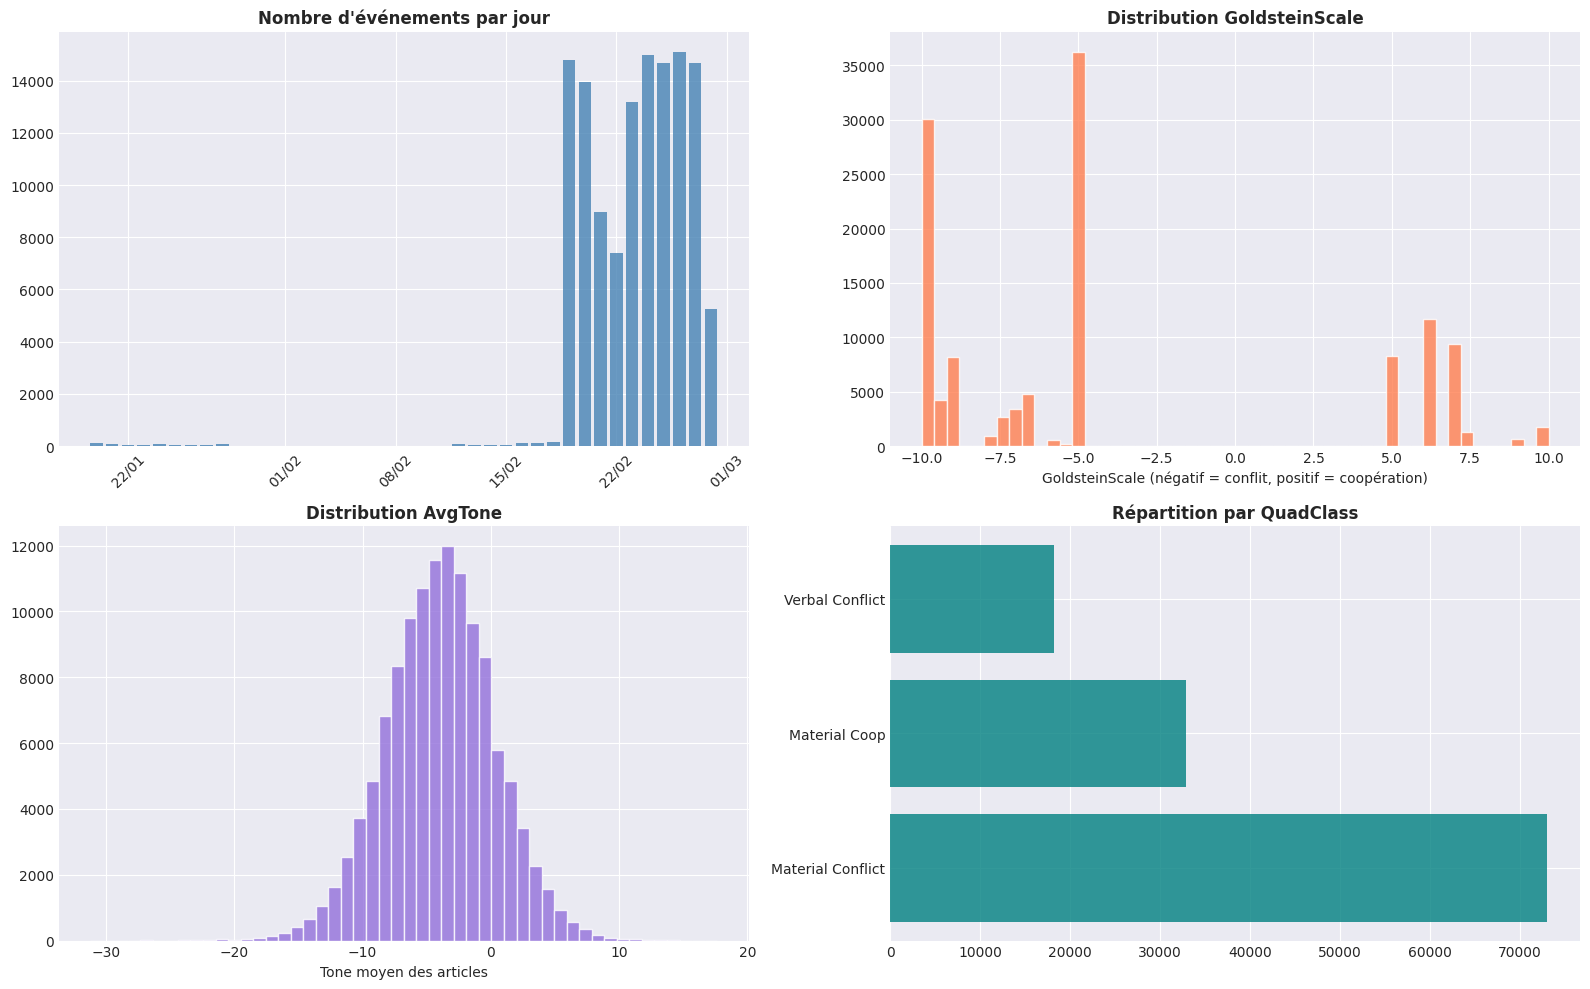

In [ ]:
# ═══════════════════════════════════════════════
# Distribution des événements GDELT
# ═══════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("seaborn-v0_8-darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Nombre d'événements par jour
if "Day" in df_gdelt.columns:
    df_gdelt["Day_dt"] = pd.to_datetime(df_gdelt["Day"], format="%Y%m%d", errors="coerce")
    daily = df_gdelt.groupby("Day_dt").size()
    axes[0, 0].bar(daily.index, daily.values, color="steelblue", alpha=0.8)
    axes[0, 0].set_title("Nombre d'événements par jour", fontweight="bold")
    axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
    axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Distribution GoldsteinScale
if "GoldsteinScale" in df_gdelt.columns:
    axes[0, 1].hist(df_gdelt["GoldsteinScale"].dropna(), bins=50, color="coral", alpha=0.8, edgecolor="white")
    axes[0, 1].set_title("Distribution GoldsteinScale", fontweight="bold")
    axes[0, 1].set_xlabel("GoldsteinScale (négatif = conflit, positif = coopération)")

# 3. Distribution AvgTone
if "AvgTone" in df_gdelt.columns:
    axes[1, 0].hist(df_gdelt["AvgTone"].dropna(), bins=50, color="mediumpurple", alpha=0.8, edgecolor="white")
    axes[1, 0].set_title("Distribution AvgTone", fontweight="bold")
    axes[1, 0].set_xlabel("Tone moyen des articles")

# 4. Top 10 QuadClass
if "QuadClass" in df_gdelt.columns:
    top_quad = df_gdelt["QuadClass"].value_counts().head(10)
    quad_labels = {1: "Verbal Coop", 2: "Material Coop", 3: "Verbal Conflict", 4: "Material Conflict"}
    top_quad.index = [quad_labels.get(int(x), str(x)) for x in top_quad.index]
    axes[1, 1].barh(top_quad.index, top_quad.values, color="teal", alpha=0.8)
    axes[1, 1].set_title("Répartition par QuadClass", fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════
# Aperçu dernières lignes GDELT
# ═══════════════════════════════════════════════
print(f"Dernières lignes :")
df_gdelt.tail(200)

Dernières lignes :


,GlobalEventID,Day,DATEADDED,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,Actor2Name,Actor2CountryCode,...,GoldsteinScale,IsRootEvent,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,NumMentions,NumSources,NumArticles,AvgTone,Day_dt
124042,1291521620,2026-02-28,2026-02-28 08:30:00,None,None,None,None,TWN,TAIWAN,TWN,...,5.0,1,TW,24.00000,121.00000,8,1,8,-1.372832,2026-02-28
124043,1291521630,2026-02-28,2026-02-28 08:30:00,None,None,None,None,USA,CALIFORNIA,USA,...,-5.0,0,US,36.17000,-119.74600,8,1,8,-3.715170,2026-02-28
124044,1291521634,2026-02-28,2026-02-28 08:30:00,None,None,None,None,USA,UNITED STATES,USA,...,-5.0,0,US,37.05010,-88.70010,4,1,4,-7.602339,2026-02-28
124045,1291521636,2026-02-28,2026-02-28 08:30:00,None,None,None,None,USA,UNITED STATES,USA,...,-10.0,1,US,43.19780,-71.56210,4,1,4,-8.333333,2026-02-28
124046,1291521655,2026-02-28,2026-02-28 08:30:00,AFR,AFRICA,AFR,None,None,None,None,...,-9.5,1,WA,-22.57000,17.08360,4,1,4,3.881512,2026-02-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124237,1291524341,2026-02-28,2026-02-28 08:45:00,UAF,TERRORIST,None,UAF,None,None,None,...,-5.0,0,NI,9.08333,7.53333,5,1,5,-5.311542,2026-02-28
124238,1291524344,2026-02-28,2026-02-28 08:45:00,UKR,UKRAINE,UKR,None,None,None,None,...,7.0,0,UP,50.43330,30.51670,5,1,5,-3.930131,2026-02-28
124239,1291524374,2026-02-28,2026-02-28 08:45:00,USA,PHOENIX,USA,None,None,None,None,...,-5.0,1,US,33.44840,-112.07400,10,1,10,-6.525573,2026-02-28
124240,1291524392,2026-02-28,2026-02-28 08:45:00,USA,THE US,USA,None,GOV,PRESIDENT,None,...,-10.0,0,IR,35.75000,51.51480,6,1,6,-3.595506,2026-02-28


In [ ]:
# ═══════════════════════════════════════════════
# Affichage des 20 premières lignes GDELT
# ═══════════════════════════════════════════════
df_gdelt.head(100)

,GlobalEventID,Day,DATEADDED,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,Actor2Name,Actor2CountryCode,...,GoldsteinScale,IsRootEvent,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,NumMentions,NumSources,NumArticles,AvgTone,Day_dt
0,1289876199,2026-02-12,2026-02-18 23:00:00,LAB,EMPLOYEE,None,LAB,USA,UNITED STATES,USA,...,-5.0,1,US,34.098300,-118.3270,6,1,6,-2.110818,2026-02-12
1,1289876202,2026-02-12,2026-02-18 23:00:00,USACOP,ALABAMA,USA,COP,None,None,None,...,-10.0,1,US,33.266800,-86.6666,6,1,6,1.403509,2026-02-12
2,1289876245,2026-02-19,2026-02-18 23:00:00,None,None,None,None,CHRCTH,CATHOLIC,None,...,-5.0,1,EI,53.000000,-8.0000,6,1,6,-1.624815,2026-02-19
3,1289876260,2026-02-19,2026-02-18 23:00:00,None,None,None,None,COP,TROOPER,None,...,-5.0,1,US,32.799000,-86.8073,10,1,10,-7.729469,2026-02-19
4,1289876332,2026-02-19,2026-02-18 23:00:00,None,None,None,None,GOV,AUTHORITIES,None,...,7.0,1,US,34.852600,-82.3940,6,1,6,-6.682028,2026-02-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1289876848,2026-02-19,2026-02-18 23:00:00,COP,DEPUTIES,None,COP,None,None,None,...,-5.0,0,US,29.550200,-95.7836,10,1,10,-1.287554,2026-02-19
96,1289876851,2026-02-19,2026-02-18 23:00:00,COP,PRISON,None,COP,None,None,None,...,-5.0,1,US,39.828175,-98.5795,5,1,5,-10.188679,2026-02-19
97,1289876854,2026-02-19,2026-02-18 23:00:00,COP,DEPUTIES,None,COP,None,None,None,...,-10.0,1,MX,23.000000,-102.0000,5,1,5,-7.843137,2026-02-19
98,1289876869,2026-02-19,2026-02-18 23:00:00,COP,POLICE,None,COP,EDU,SCHOOL,None,...,-10.0,1,None,NaN,NaN,15,1,15,-2.097902,2026-02-19


In [ ]:
print(df_gdelt.iloc[110])

GlobalEventID                     1289877324
Day                               2026-02-19
DATEADDED                2026-02-18 23:00:00
Actor1Code                               GOV
Actor1Name                         PRESIDENT
Actor1CountryCode                       None
Actor1Type1Code                          GOV
Actor2Code                               MIL
Actor2Name                          MILITARY
Actor2CountryCode                       None
Actor2Type1Code                          MIL
EventCode                                127
EventRootCode                             12
QuadClass                                  3
GoldsteinScale                          -5.0
IsRootEvent                                1
ActionGeo_CountryCode                     IR
ActionGeo_Lat                           32.0
ActionGeo_Long                          53.0
NumMentions                               10
NumSources                                 1
NumArticles                               10
AvgTone   

In [ ]:
# Filtrer les lignes avec OPC en Actor1Code ou Actor2Code
df_opc = df_gdelt[(df_gdelt['Actor1Code'] == 'GOVOPC') | (df_gdelt['Actor2Code'] == 'GOVOPC')]

print(f"Nombre de lignes avec OPC : {len(df_opc)}")
df_opc.head(50)

Nombre de lignes avec OPC : 0


,GlobalEventID,Day,DATEADDED,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,Actor2Name,Actor2CountryCode,...,GoldsteinScale,IsRootEvent,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,NumMentions,NumSources,NumArticles,AvgTone,Day_dt


In [ ]:
import numpy as np

# ═══════════════════════════════════════════════
# Ajout des colonnes "buzz" et "gravité pondérée"
# ═══════════════════════════════════════════════


# Création d'une copie du dataset filtré pour ajouter les nouvelles colonnes
df_gdelt_enriched = filter_all.copy()

# Calcul de "Le buzz" : log(1 + NumArticles)
df_gdelt_enriched['buzz'] = np.log(1 + df_gdelt_enriched['NumArticles'])

# Calcul de "La Gravité pondérée" : (10 - Goldstein) × (1 + (100 - AvgTone) / 50)
df_gdelt_enriched['gravite_ponderee'] = (
    (10 - df_gdelt_enriched['GoldsteinScale']) * 
    (1 + (100 - df_gdelt_enriched['AvgTone']) / 50)
)

print(f"✅ Nouvelles colonnes ajoutées : 'buzz' et 'gravite_ponderee'")
print(f"📊 Shape du dataset enrichi : {df_gdelt_enriched.shape[0]} lignes × {df_gdelt_enriched.shape[1]} colonnes\n")
print("=" * 150)
print("Aperçu des 100 premières lignes :\n")
df_gdelt_enriched.head(100)
df_gdelt_enriched.describe()


NameError: name 'filter_all' is not defined

In [ ]:
# ═══════════════════════════════════════════════
# Analyse de l'impact des filtres avec EventRootCode
# ═══════════════════════════════════════════════

relevant_event_codes = [6, 8,10,11,12, 13, 14, 15, 16, 17, 18, 19, 20]

df_base = df_gdelt.copy()
total = len(df_base)

# Calcul de chaque filtre individuellement
f_eventroot = df_base['EventRootCode'].isin(relevant_event_codes)
f_numart    = df_base['NumArticles'] >= 4
f_goldstein = df_base['GoldsteinScale'].abs() >= 5
f_quadclass = df_base['QuadClass'] >= 2

# Construction du tableau d'impact
filters_summary = [
    ("Aucun filtre (données initiales)",                       total),
    ("EventRootCode ∈ liste",                                  f_eventroot.sum()),
    ("NumArticles >= 4",                                       f_numart.sum()),
    ("|GoldsteinScale| >= 5",                                  f_goldstein.sum()),
    ("QuadClass >= 2",                                         f_quadclass.sum()),
    ("EventRootCode ∈ liste ET NumArticles >= 4",              (f_eventroot & f_numart).sum()),
    ("EventRootCode ∈ liste ET |GoldsteinScale| >= 5",         (f_eventroot & f_goldstein).sum()),
    ("EventRootCode ∈ liste ET QuadClass >= 2",                (f_eventroot & f_quadclass).sum()),
    ("NumArticles >= 4 ET |GoldsteinScale| >= 5",              (f_numart & f_goldstein).sum()),
    ("NumArticles >= 4 ET QuadClass >= 2",                     (f_numart & f_quadclass).sum()),
    ("|GoldsteinScale| >= 5 ET QuadClass >= 2",                (f_goldstein & f_quadclass).sum()),
    ("TOUS LES FILTRES COMBINÉS",                              (f_numart & f_goldstein & f_quadclass).sum()),
]

results_extended = pd.DataFrame(filters_summary, columns=["Filtre(s) appliqué(s)", "Nombre de lignes"])
results_extended["% restant"]  = (results_extended["Nombre de lignes"] / total * 100).round(2)
results_extended["Lignes retirées"] = total - results_extended["Nombre de lignes"]
results_extended["% retiré"]   = (results_extended["Lignes retirées"] / total * 100).round(2)

print(f"Total initial : {total:,} lignes\n")
print(f"Codes EventRootCode conservés : {relevant_event_codes}\n")
display(results_extended)

# Aperçu du dataset final avec tous les filtres combinés
df_final = df_base[f_numart & f_goldstein & f_quadclass].copy()
print(f"\n✅ Dataset final (tous filtres) : {len(df_final):,} lignes × {df_final.shape[1]} colonnes")
df_final.head(20)

In [ ]:
# Affichage des 20 premières lignes du GDELT
df_gdelt.head(20)

NameError: name 'df_gdelt' is not defined